# Chapter 12 — Meta-learning a prior over kernels

*Companion notebook to **The Learned Kernel**, Ch. 12. Run top to bottom.*

In Chapter 8 the geometry of one table was a spectral measure **m**, fit by gradient descent on
that table's evidence — one optimization per table. **Amortization** asks a different question: can
a single map, learned once across many tasks, **infer** m from a context set of (x, y) pairs in one
forward pass, with nothing fit per table? The move that makes it answerable: draw the meta-training
tasks from the model's **own** kernel prior. Then generator and inferrer share one geometry, the
problem is **well specified**, the Bayes-optimal predictor is the GP posterior mean at the true m,
and the cost of inference is measurable exactly — the **regret over Bayes**.

**The frame** — *what is learned · how scored · what you read off.* What: the amortized map
gθ: context → measure m. Scored: regret(k) = E[MSE(emitter)] − E[MSE(Bayes)] ≥ 0. Read off: the
regret curve — bounded, non-vanishing, leveling — an **amortization cost**, not a misspecification.

## Setup

A GPU is recommended (meta-training is a short Transformer training run); it falls back to CPU.

In [1]:
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

from lkbook import set_style
from lkbook.chapters import ch12

set_style()
device = ch12._device()
print("device:", device)

device: cuda


### The measure **m**, its kernel, and the emitter — formula ↔ code

A measure collects the adaptable parameters of the Ch. 8 kernel:
**m** = ( {μ, γ, π}ₕⱼ_q per-coordinate spectral density · {sⱼ} ARD relevances · {Tₕ} bandwidths ·
{wₕ} fusion weights ). The pieces map one-to-one to functions in `ch12`:

- **density → atoms** `density_to_atoms`: ω = |μ + √2·γ·ξ_g|, a² = π·w̃_g (Gauss–Hermite quadrature).
- **spectral features** `feature_map`: ψₕ(x) = [a·cos(2π sⱼ xⱼ ω), a·sin(2π sⱼ xⱼ ω)], warped φₕ = W·ψₕ.
- **fused kernel** `gram`: K_m(x, x′) = Σₕ wₕ · exp( −‖φₕ(x) − φₕ(x′)‖ / Tₕ ),  w = softmax.
- **emitter** `MetaMSSKM.emit`: tokens uₐ = Linear([xₐ, yₐ]) → TransformerEncoder → **attention pool** e
  → linear heads → (ω, a, s, T, w, σ²). W and the quadrature are **shared** (frozen); only m is emitted.
- **hyperprior** `sample_measure_prior` · **GP draw** `sample_gp_tasks` (y = Lz, LLᵀ = K_m + σ²I) ·
  **Bayes** `bayes_posterior` = the same in-context KRR `krr_incontext` at the *true* m.

## 12.1  The self-consistent prior

A measure **m** defines a kernel **K_m**, which defines a Gaussian process, which is a generative
model of functions. So we can sample tasks from the model's own prior: draw m from a hyperprior,
build K_m, draw y ~ GP(0, K_m + σ²I). Because the **generating** kernel and the **emitted** kernel
lie in the same family (same shared geometry W, same quadrature), the generative class equals the
hypothesis class — the problem is **well specified** and the Bayes-optimal predictor is known.

The same **m** that draws the task also decodes the Bayes predictor, so the optimum is exact.

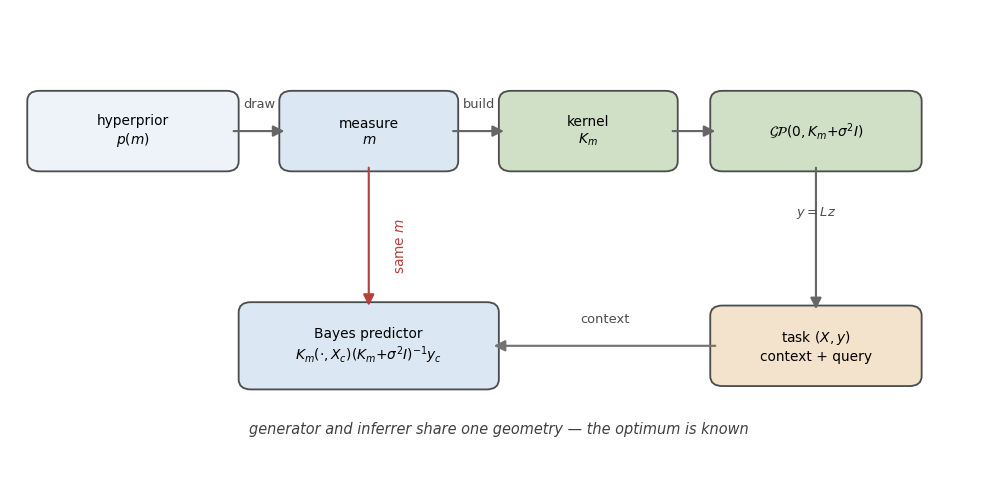

In [3]:
ch12.make_pipeline_figure()
plt.show()

One element determines whether the tasks are *learnable*: **bandwidth calibration**. A fixed random geometry
W and high frequencies push embedding distances past any fixed bandwidth, the Gram collapses to the
identity, and the GP draw is white noise. Calibrating each task's bandwidth to its own mean pairwise
embedding distance (Tₕ ← τₕ·ρ̄) keeps the tasks predictable — so Bayes beats predict-the-mean by a
wide margin. We confirm this directly on a batch drawn from the prior.

In [4]:
import torch
import torch.nn.functional as F

g = torch.Generator(device=device).manual_seed(0)
nodes, wts = np.polynomial.hermite.hermgauss(6)
gh = (torch.as_tensor(nodes, dtype=torch.float32, device=device),
      torch.as_tensor(wts / np.sqrt(np.pi), dtype=torch.float32, device=device))
W = 0.1 * torch.randn(64, 8 * 2 * 18, generator=g, device=device)
m, s2 = ch12.sample_measure_prior(64, 8, 4, 3, *gh, W, g, device=device)
Xc, yc, Xq, yq = ch12.sample_gp_tasks(m, 64, 64, s2, g, device=device)
bayes = ch12.bayes_posterior(m, Xc, yc, Xq, s2)
print(f"Bayes MSE        {F.mse_loss(bayes, yq).item():.3f}")
print(f"predict-mean MSE {F.mse_loss(torch.zeros_like(yq), yq).item():.3f}")
print("→ calibration makes the tasks learnable: Bayes is well below the mean.")

Bayes MSE        0.869
predict-mean MSE 1.036
→ calibration makes the tasks learnable: Bayes is well below the mean.


## 12.2  Meta-train the emitter; regret over Bayes

The emitter is a permutation-invariant Transformer: it embeds each (x, y) pair as a token, lets the
tokens attend, **pools by attention** into one summary, and reads off the measure with linear heads.
The shared geometry W and quadrature are frozen; only the **measure** adapts to the context. We
meta-train on the prior stream, then on **held-out** tasks report the regret over Bayes vs context
size k. Both the emitter and Bayes decode by the **same** in-context KRR solve, so the regret is a
one-line subtraction isolating the cost of *inferring* m from k examples versus *knowing* it.

**The training loop** (`meta_train`). The emitter predicts queries by the in-context KRR readout
f̂_θ(X_q) = K_m̂(X_q, X_c)·(K_m̂(X_c, X_c) + σ̂²I)⁻¹·y_c with m̂ = gθ(context), and θ minimizes the
expected **query MSE** over the task stream, L(θ) = E_m E_(X,y) ‖f̂_θ(X_q) − y_q‖². Each step: (1)
sample k ∈ {16,…,256}; (2) for b = 1…B draw m_b from the hyperprior (current W), draw X_b, calibrate
bandwidths, draw y_b = Lz, split; (3) predict queries by in-context KRR; (4) Adam step on the mean
query MSE, **W frozen**. The loss uses no knowledge of the true m — only the queries — so the same
loop runs unchanged on a real table; the true m enters only to *score*, next.

In [5]:
# Train once (modest budget for the notebook; the book uses steps=3000, n_tasks=400).
res = ch12.run_all(steps=1500, n_tasks=200, pool="pma", seed=0, device=device, log_every=500)
net = res["net"]

print("\n  k   emitter   bayes   regret    mean")
for k in res["ks"]:
    r = res["regret"][k]
    print(f"{k:>4}   {r['emitter']:.3f}   {r['bayes']:.3f}   {r['regret']:+.3f}   {r['mean']:.3f}")

  step   500  meta-train MSE 1.1079  (n_ctx=64)


  step  1000  meta-train MSE 1.0338  (n_ctx=256)


  step  1500  meta-train MSE 1.0285  (n_ctx=256)



  k   emitter   bayes   regret    mean
   8   1.574   1.531   +0.043   1.574
  32   1.122   0.989   +0.134   1.122
  64   1.042   0.855   +0.187   1.042
 128   1.030   0.766   +0.264   1.030
 256   1.000   0.680   +0.320   1.000
 512   1.001   0.610   +0.391   1.001


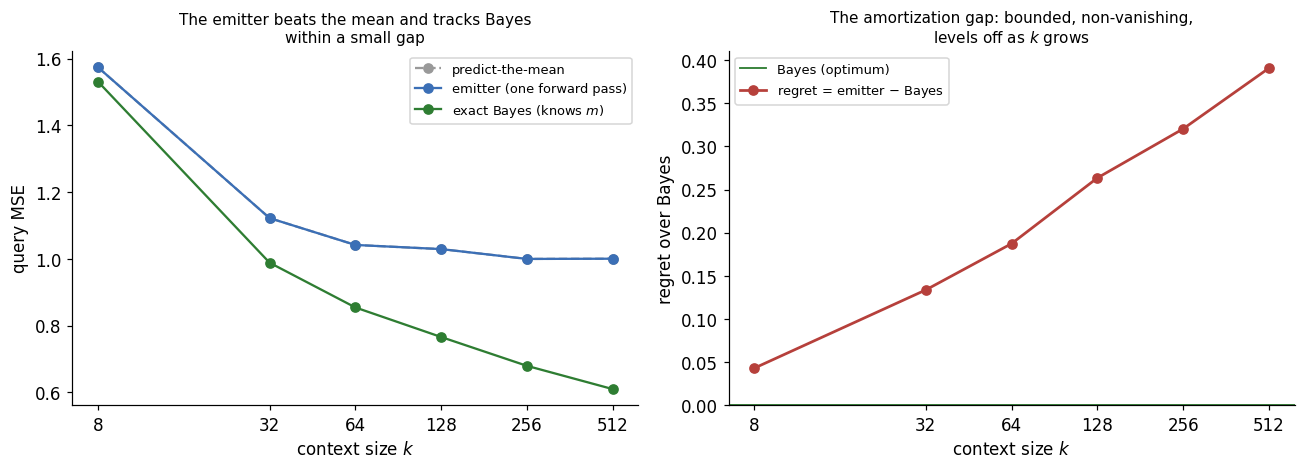

In [6]:
ch12.make_regret_figure(res)
plt.show()

The emitter beats predict-the-mean at **every** k and trails exact Bayes by a **small bounded gap**
that **levels off** rather than vanishing. The gap does not close as k grows (Bayes extracts signal
from a larger context faster than a one-pass map can) but it does not diverge either. This plateau
is an **amortization cost** — the price of compressing a context into a measure in one forward pass.
Enlarging the emitted measure does **not** lower it (the residual is the *context* being too small to
pin a measure exactly, not the measure being too small); the fix is a better encoder — Chapter 13.

## 12.3  Zero-shot transfer to real data (the Ch. 14 teaser)

Freeze the emitter and predict a held-out **California Housing** task from a context subsample of the
training rows alone — **no per-dataset gradient steps**. The number is now governed by how well the
synthetic prior resembles the real table — the **prior↔reality gap** — not by the regret of the
controlled world. That gap is the subject of Chapter 14.

In [7]:
tr = ch12.zeroshot_transfer(net, d_max=8, seed=0, device=device)
print(f"zero-shot California R² = {tr['emitter']:.3f}   (frozen emitter, context-only)")

zero-shot California R² = -0.000   (frozen emitter, context-only)


### How bad is amortization? — vs per-dataset training, and the role of the prior

Two measurements separate **amortizing the inference** (one pass vs fitting) from a **misspecified
prior** (synthetic vs real).

1. **In-distribution** (tasks from the prior): compare Bayes (knows m), a **per-dataset gradient
   fit** on the same context (Chapter 8, the slow way), and the **one-pass emitter**. The emitter
   *matches* per-dataset fitting at large k and *beats* it at small k (where fitting overfits) — so
   the amortization cost is ≈ 0. Both trail Bayes by the **finite-context** gap, the price any
   fitter pays for a finite sample.
2. **Real California:** the synthetic-prior emitter reaches R² ≈ 0.55 vs the per-dataset fit's 0.80.
   That gap is **not** amortization — meta-training the *same architecture* in-context on **real**
   California sub-tasks (random context/query splits of the train rows, real labels, still no
   per-dataset gradient steps at test) reaches **0.80**, matching per-dataset. The binding
   constraint is the **prior↔reality match**, the open problem of Chapter 14.

in-distribution held-out R²  (Bayes / per-dataset GD / emitter):
  k= 64:  Bayes +0.161   per-dataset -0.149   emitter -0.010   ->  amortization cost -0.139
  k=256:  Bayes +0.336   per-dataset +0.181   emitter -0.009   ->  amortization cost +0.190



California held-out R²:  synthetic-prior -0.004   in-context-on-real 0.806   per-dataset Ch8 0.795


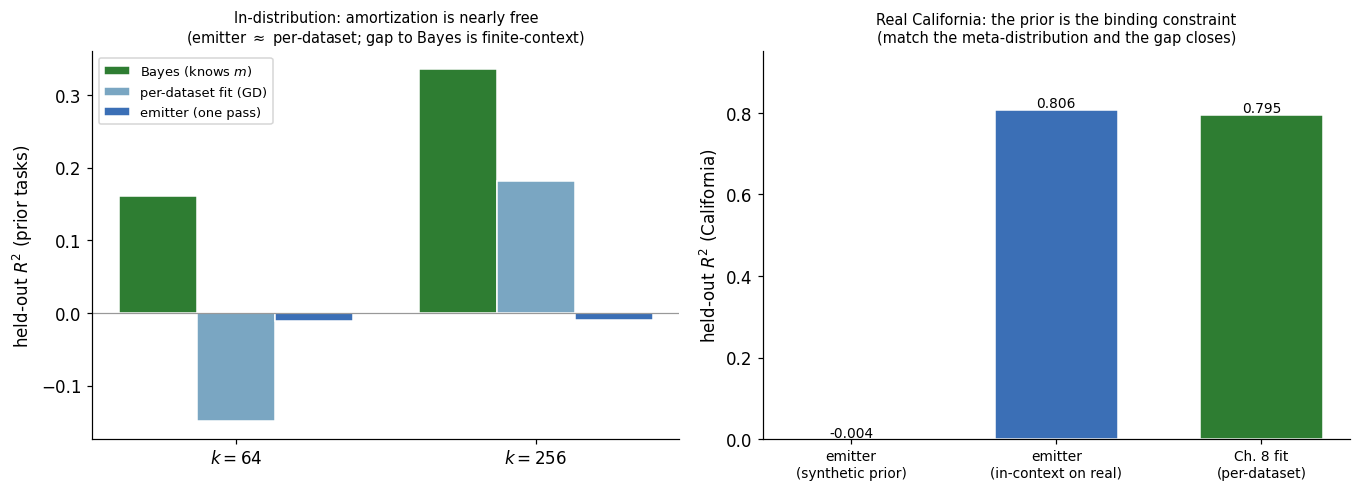

In [8]:
decomp = ch12.decompose_amortization(net, ks=(64, 256), n_tasks=16, device=device)
print("in-distribution held-out R²  (Bayes / per-dataset GD / emitter):")
for k in decomp:
    d = decomp[k]
    print(f"  k={k:>3}:  Bayes {d['bayes']:+.3f}   per-dataset {d['per_dataset']:+.3f}   "
          f"emitter {d['emitter']:+.3f}   ->  amortization cost {d['per_dataset']-d['emitter']:+.3f}")

# Ceiling: meta-train in-context on REAL California sub-tasks (trains a fresh emitter, ~40s on GPU)
synth = ch12.recover_vs_chapter8(net, seed=0, device=device)
ceil = ch12.ceiling_incontext_real(steps=3000, seed=0, device=device)
calif = {"synthetic": synth["r2_emitter"], "ceiling": ceil[512][0], "ch8": ceil["ch8"]}
print(f"\nCalifornia held-out R²:  synthetic-prior {calif['synthetic']:.3f}   "
      f"in-context-on-real {calif['ceiling']:.3f}   per-dataset Ch8 {calif['ch8']:.3f}")
ch12.make_recovery_figure(decomp, calif)
plt.show()

## Explorer — one task, the emitter against Bayes

Draw one held-out task from the prior at context size **k** and compare the emitter's one-pass
prediction to the exact Bayes posterior. As k grows, both improve and the emitter's shortfall (the
regret) settles to a small bounded gap.

In [9]:
from ipywidgets import interact, IntSlider


def explore(k=64):
    e = ch12.explore_task(net, k=k, n_q=150, seed=7, device=device)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
    lim = [min(e["yq"].min(), e["bayes"].min(), e["emitter"].min()) - 0.2,
           max(e["yq"].max(), e["bayes"].max(), e["emitter"].max()) + 0.2]
    ax[0].plot(lim, lim, "0.6", lw=0.9)
    ax[0].scatter(e["yq"], e["bayes"], s=16, alpha=0.6, color="#2e7d32", label="Bayes")
    ax[0].scatter(e["yq"], e["emitter"], s=16, alpha=0.6, color="#3b6fb6", label="emitter")
    ax[0].set_xlabel("true query value"); ax[0].set_ylabel("prediction")
    ax[0].set_title(f"k = {k}: predictions vs truth"); ax[0].legend(fontsize=9)
    bars = [e["mse_mean"], e["mse_emitter"], e["mse_bayes"]]
    ax[1].bar([0, 1, 2], bars, width=0.6, color=["0.6", "#3b6fb6", "#2e7d32"], edgecolor="white")
    ax[1].set_xticks([0, 1, 2]); ax[1].set_xticklabels(["predict-mean", "emitter", "Bayes"])
    ax[1].set_ylabel("query MSE")
    ax[1].set_title(f"regret = {e['mse_emitter'] - e['mse_bayes']:+.3f}")
    for x, v in zip([0, 1, 2], bars):
        ax[1].text(x, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    plt.show()


interact(explore, k=IntSlider(min=8, max=256, step=8, value=64, description="k"));

interactive(children=(IntSlider(value=64, description='k', max=256, min=8, step=8), Output()), _dom_classes=('…

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(easy)** Confirm regret ≥ 0 empirically across context sizes, and that the emitter always beats
predict-the-mean, from the held-out evaluation.

In [10]:
# TODO: print regret and (mean - emitter) for each k in res["ks"]; check both are positive.

<details><summary>Solution</summary>

```python
for k in res["ks"]:
    r = res["regret"][k]
    print(k, "regret", round(r["regret"], 3), " mean-emitter", round(r["mean"] - r["emitter"], 3))
```
Regret is nonnegative because Bayes is the conditional mean, the minimizer of squared error; the
emitter beats the mean because the inferred measure carries real signal.
</details>

**(medium)** Show that enlarging the emitted measure does not lower the regret floor. Train a
second emitter with more banks/components (H=6, Q=6) and compare its regret at large k.

In [11]:
# TODO: train ch12.train_emitter(H=6, Q=6, steps=1500) and eval_regret_vs_k; compare to res.

<details><summary>Solution</summary>

```python
net2 = ch12.train_emitter(H=6, Q=6, steps=1500, device=device, seed=0)
rows2 = ch12.eval_regret_vs_k(net2, 8, 6, 6, ks=(128, 256, 512), n_tasks=200, device=device)
for k in (128, 256, 512):
    print(k, "H4Q3", round(res["regret"][k]["regret"], 3),
             "H6Q6", round(rows2[k]["regret"], 3))
```
The larger measure does not lower the floor (and can raise it): a bigger measure is harder to infer
from the same context. The residual is an amortization cost of the one-pass inference — a property
of the **context**, not of the measure's capacity.
</details>

**(⋆)** The emitter and Bayes differ only in the measure passed to one shared KRR solver. Verify
that at very large k the emitter's measure approaches the true one by checking the regret shrinks
toward — but does not reach — zero, and explain why a fixed-capacity one-pass map cannot reach it.

In [12]:
# TODO: evaluate regret at k in (256, 512) with more tasks; discuss the plateau.

<details><summary>Solution</summary>

Bayes is *consistent* (it knows m and its posterior contracts as k grows), but the emitter must
compress the whole context into a measure in **one forward pass** with fixed capacity. Past some k
the bottleneck is that compression, not the measure family, so the regret plateaus at a positive
amortization floor. A better aggregator (attention pooling vs a uniform mean) narrows it; more
measure capacity does not. This is the bridge to Chapter 13.
</details>